# Wczytanie bibliotek i bazy danych

In [516]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt

import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from wordcloud import WordCloud

from wordcloud import WordCloud, STOPWORDS

nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

%matplotlib inline
sns.set()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [517]:
original_df = pd.read_csv('movies.csv',index_col='index')
df = original_df.copy()

In [518]:
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
index,,,,,,,,,,,,,,,,,,,,,
0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


# Przygotowanie danych

In [519]:
df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'cast', 'crew', 'director'],
      dtype='object')

In [520]:
df = df[['title', 'genres', 'keywords', 'original_language', 'original_title',
         'overview', 'production_countries', 'cast', 'director']]
df.head()

,title,genres,keywords,original_language,original_title,overview,production_countries,cast,director
index,,,,,,,,,
0,Avatar,Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",Sam Worthington Zoe Saldana Sigourney Weaver S...,James Cameron
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",Johnny Depp Orlando Bloom Keira Knightley Stel...,Gore Verbinski
2,Spectre,Action Adventure Crime,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,"[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,Sam Mendes
3,The Dark Knight Rises,Action Crime Drama Thriller,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""iso_3166_1"": ""US"", ""name"": ""United States o...",Christian Bale Michael Caine Gary Oldman Anne ...,Christopher Nolan
4,John Carter,Action Adventure Science Fiction,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",Taylor Kitsch Lynn Collins Samantha Morton Wil...,Andrew Stanton


In [521]:
df.shape

(4803, 9)

In [522]:
df.duplicated().value_counts()

,count
False,4803


<Axes: ylabel='index'>

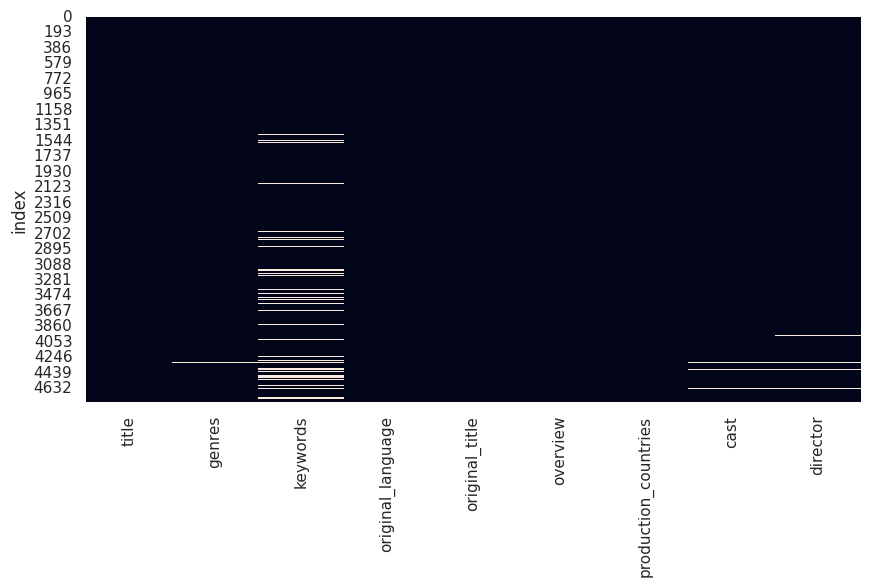

In [523]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)

In [524]:
df.isna().sum()

,0
title,0
genres,28
keywords,412
original_language,0
original_title,0
overview,3
production_countries,0
cast,43
director,30


* Brakujące wartości w `director`, `genres` i `cast` uzupełniamy jako `Unknown`.
* Brakujące wartości w `keywords` i `overview` zostawiamy "puste".

In [525]:
df[['director','genres','cast']] = df[['director','genres', 'cast']].fillna('Unknown')
df[['keywords', 'overview']] = df[['keywords', 'overview']].fillna('')

In [526]:
import ast

def extract_names(val):
    if pd.isna(val) or val == "":
        return None

    try:
        data = ast.literal_eval(val)

        if isinstance(data, list):
            return ", ".join([i['name'] for i in data if 'name' in i])

        if isinstance(data, dict):
            return data.get('name')

    except (ValueError, SyntaxError):
        return val

df['production_countries'] = df['production_countries'].apply(extract_names)
df.head()

,title,genres,keywords,original_language,original_title,overview,production_countries,cast,director
index,,,,,,,,,
0,Avatar,Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...","United States of America, United Kingdom",Sam Worthington Zoe Saldana Sigourney Weaver S...,James Cameron
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",United States of America,Johnny Depp Orlando Bloom Keira Knightley Stel...,Gore Verbinski
2,Spectre,Action Adventure Crime,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,"United Kingdom, United States of America",Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,Sam Mendes
3,The Dark Knight Rises,Action Crime Drama Thriller,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,United States of America,Christian Bale Michael Caine Gary Oldman Anne ...,Christopher Nolan
4,John Carter,Action Adventure Science Fiction,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",United States of America,Taylor Kitsch Lynn Collins Samantha Morton Wil...,Andrew Stanton


In [527]:
df.production_countries.value_counts()

,count
production_countries,
United States of America,2977
"United Kingdom, United States of America",181
,174
United Kingdom,131
"Germany, United States of America",119
...,...
"United Kingdom, South Africa",1
"United States of America, France, Mexico",1
"Mexico, Spain",1


Dla uproszczenia analizy, jako kraj produkcji zostawiamy tylko pierwszy z wymienionych.

In [528]:
df['production_countries'] = df['production_countries'].apply(lambda x: x.split(',')[0])

In [529]:
df = df.rename(columns={'production_countries': 'country'})
df.head()

,title,genres,keywords,original_language,original_title,overview,country,cast,director
index,,,,,,,,,
0,Avatar,Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",United States of America,Sam Worthington Zoe Saldana Sigourney Weaver S...,James Cameron
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",United States of America,Johnny Depp Orlando Bloom Keira Knightley Stel...,Gore Verbinski
2,Spectre,Action Adventure Crime,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,United Kingdom,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,Sam Mendes
3,The Dark Knight Rises,Action Crime Drama Thriller,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,United States of America,Christian Bale Michael Caine Gary Oldman Anne ...,Christopher Nolan
4,John Carter,Action Adventure Science Fiction,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",United States of America,Taylor Kitsch Lynn Collins Samantha Morton Wil...,Andrew Stanton


In [530]:
df.country.value_counts()

,count
country,
United States of America,3102
United Kingdom,374
Canada,220
Germany,200
France,174
...,...
Slovenia,1
Afghanistan,1
Dominican Republic,1


# Analiza eksploracyjna

Text(0.5, 1.0, 'Top 10 reżyserów według liczby nakręconych filmów')

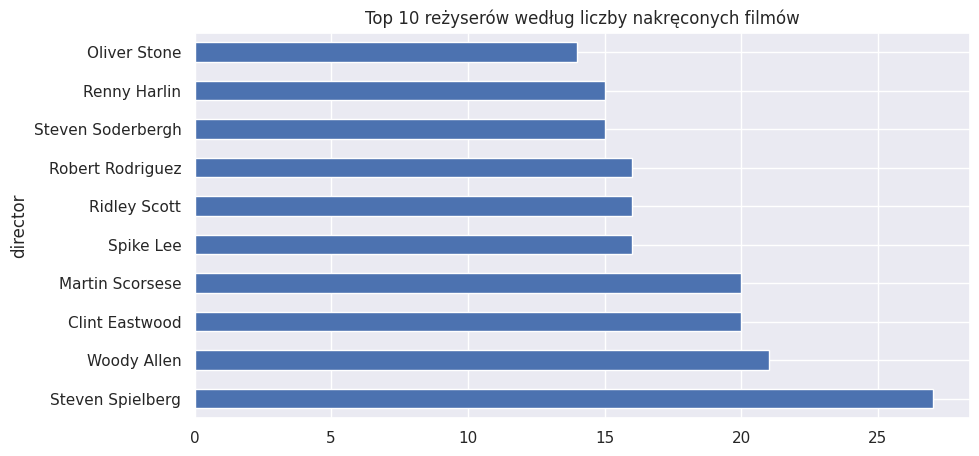

In [531]:
plt.figure(figsize=(10,5))
df[~(df['director']=='Unknown')].director.value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 reżyserów według liczby nakręconych filmów')

Text(0.5, 1.0, 'Top 10 krajów ze względu na największą liczbę wyprodukowanych filmów')

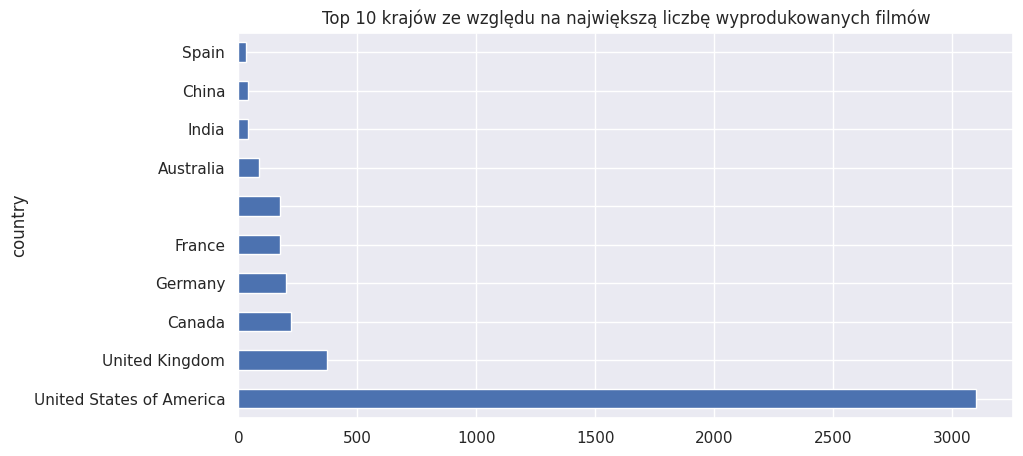

In [532]:
plt.figure(figsize=(10,5))
df[~(df['country']=='Unknown')].country.value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 krajów ze względu na największą liczbę wyprodukowanych filmów')

# Algorytm k-średnich: wydzielenie klastrów ze względu na `keywords`, `overview`, `genres`, `cast` i `director`

In [533]:
df['content'] = df['keywords'] + " " + df['overview'] + " " + df['genres'] + " " + df['cast'] + " " + df['director']

In [534]:
# lista ze stopwords
sw = stopwords.words('english')
sw.extend(['one', 'two', 'three', 'new', 'find', 'take', 'must', 'world', 'become']) # uzupełniamy o wyrazy "zaśmiecające" klastry

In [535]:
lemmatizer = WordNetLemmatizer()

In [536]:
def clean_text(text):
    # małe litery i usuwanie interpunkcji
    text = text.lower()
    text = "".join([char for char in text if char not in string.punctuation])

    # tokenizacja, usuwanie stop-words i lematyzacja
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in sw]

    return " ".join(cleaned_words)

In [537]:
df['content'] = df['content'].apply(clean_text)
df['content'][20]

'loss father vigilante serum marvel comic scientific experiment peter parker outcast high schooler abandoned parent boy leaving raised uncle ben aunt may like teenager peter trying figure got person today peter discovers mysterious briefcase belonged father begin quest understand parent disappearance – leading directly oscorp lab dr curt connors father former partner spiderman set collision course connors alter ego lizard peter make lifealtering choice use power shape destiny hero action adventure fantasy andrew garfield emma stone rhys ifans denis leary campbell scott marc webb'

In [538]:
tfidf = TfidfVectorizer(max_features=2500, min_df=2)
tfidf_matrix = tfidf.fit_transform(df['content'])

# redukcja wymiaru (LSA)
svd = TruncatedSVD(n_components=200, random_state=42)
svd_feats = svd.fit_transform(tfidf_matrix)

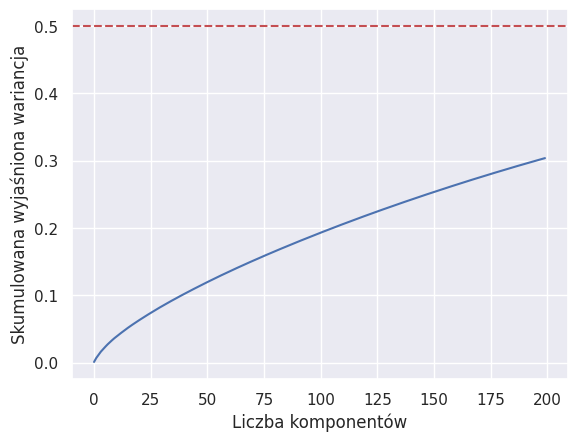

In [541]:
cum_variance = np.cumsum(svd.explained_variance_ratio_)

plt.plot(cum_variance)
plt.xlabel('Liczba komponentów')
plt.ylabel('Skumulowana wyjaśniona wariancja')
plt.axhline(y=0.5, color='r', linestyle='--')
plt.show()

Dla 200 komponentów wariancja jest wyjaśniana w ok. 30%. W analizie tekstu jest to wynik optymalny - pozwala skupić się na głównych tematach (np. gatunkach), odrzucając nieistotne szczegóły i szum językowy.

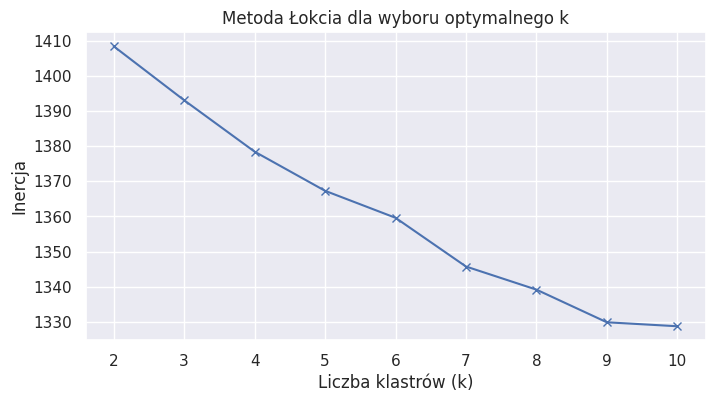

In [539]:
# metoda łokcia - wybór optymalnego k (liczba klastrów)
inertia = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(svd_feats)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inercja')
plt.title('Metoda Łokcia dla wyboru optymalnego k')
plt.show()

Po przekroczeniu $k=7$, linia zaczyna się spłaszczać, stąd $k=7$ jest naszym głównym łokciem, dla którego powinniśmy otrzymać stabilne i wyraźnie odseparowane od siebie grupy.

In [540]:
num_clusters = 7
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(svd_feats)

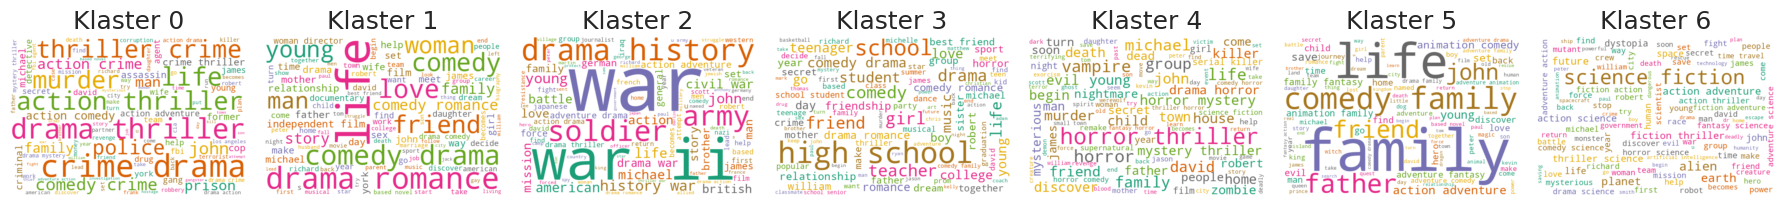

In [542]:
fig, axes = plt.subplots(1, num_clusters, figsize=(18, 10))
axes = axes.flatten()

for i in range(num_clusters):
    cluster_text = " ".join(df[df['cluster'] == i]['content'])

    if cluster_text.strip():
        wc = WordCloud(width=600, height=400, background_color='white',
                       max_words=100, colormap='Dark2').generate(cluster_text)

        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f'Klaster {i}', fontsize=18)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

* Klaster 0: kryminały, thrillery, filmy akcji
* Klaster 1: komedie romantyczne, filmy o życiu, miłości i przyjaźni
* Klaster 2: filmy wojenne, historyczne
* Klaster 3: komedie i dramaty dla nastolatków, filmy o szkole
* Klaster 4: filmy fantasy, horrory, mystery
* Klaster 5: komedie, filmy familijne, przygodowe
* Klaster 6: filmy sci-fi, przygodowe, dystopijne


In [543]:
print("\nPrzykładowe filmy w klastrach:")
for i in range(num_clusters):
    titles = df[df['cluster'] == i]['title'].head(5).values
    print(f"Klaster {i}: {', '.join(titles)}")


Przykładowe filmy w klastrach:
Klaster 0: Spectre, The Dark Knight Rises, Quantum of Solace, The Lone Ranger, Skyfall
Klaster 1: King Kong, Titanic, The Great Gatsby, The Curious Case of Benjamin Button, Hancock
Klaster 2: Captain America: Civil War, Pearl Harbor, Alexander, Troy, The Last Samurai
Klaster 3: Spider-Man, Grown Ups, Alvin and the Chipmunks: The Squeakquel, Mona Lisa Smile, Red Dawn
Klaster 4: The Wolfman, Ghost Rider, Dante's Peak, End of Days, What Lies Beneath
Klaster 5: Pirates of the Caribbean: At World's End, Spider-Man 3, Tangled, Harry Potter and the Half-Blood Prince, Batman v Superman: Dawn of Justice
Klaster 6: Avatar, John Carter, Avengers: Age of Ultron, Superman Returns, Man of Steel


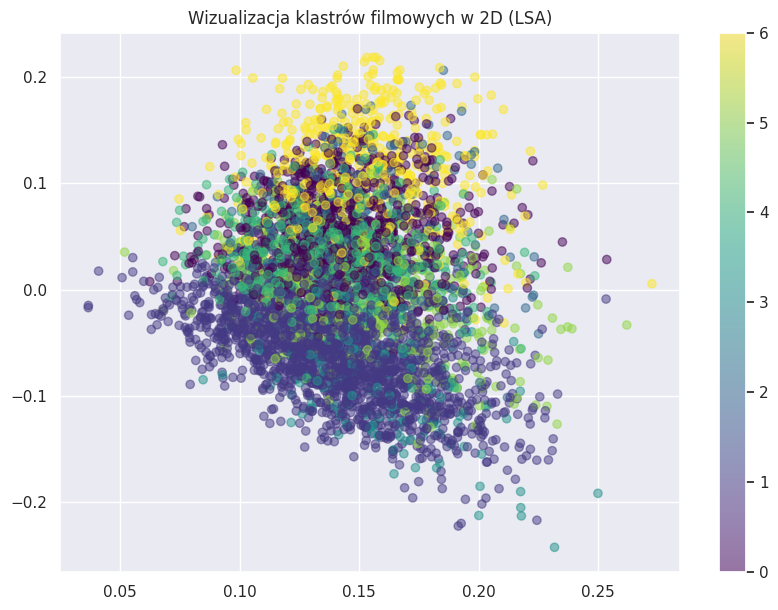

In [550]:
svd_2d = TruncatedSVD(n_components=2, random_state=42)
coords = svd_2d.fit_transform(tfidf_matrix)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=df['cluster'], cmap='viridis', alpha=0.5)
plt.title('Wizualizacja klastrów filmowych w 2D (LSA)')
plt.colorbar(scatter)
plt.show()